In [69]:
import seaborn as sns
from cycler import cycler

main_colours = ["#b83737", "#4C6A92", "#D0AA4A"]
edge_colour = "#131313"

custom_params = {
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.markeredgecolor": edge_colour,
    "lines.markeredgewidth": 1.25,
    "figure.dpi": 200,
    "text.usetex": True,
    "font.family": "serif",
    "axes.prop_cycle": cycler(color=main_colours),  }

sns.set_theme(
    context="talk",
    style="ticks",
    rc=custom_params
)

/var/folders/cn/hc6sy9vj2vlchg2np1k_bvvh0000gn/T/ipykernel_5940/1450461136.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


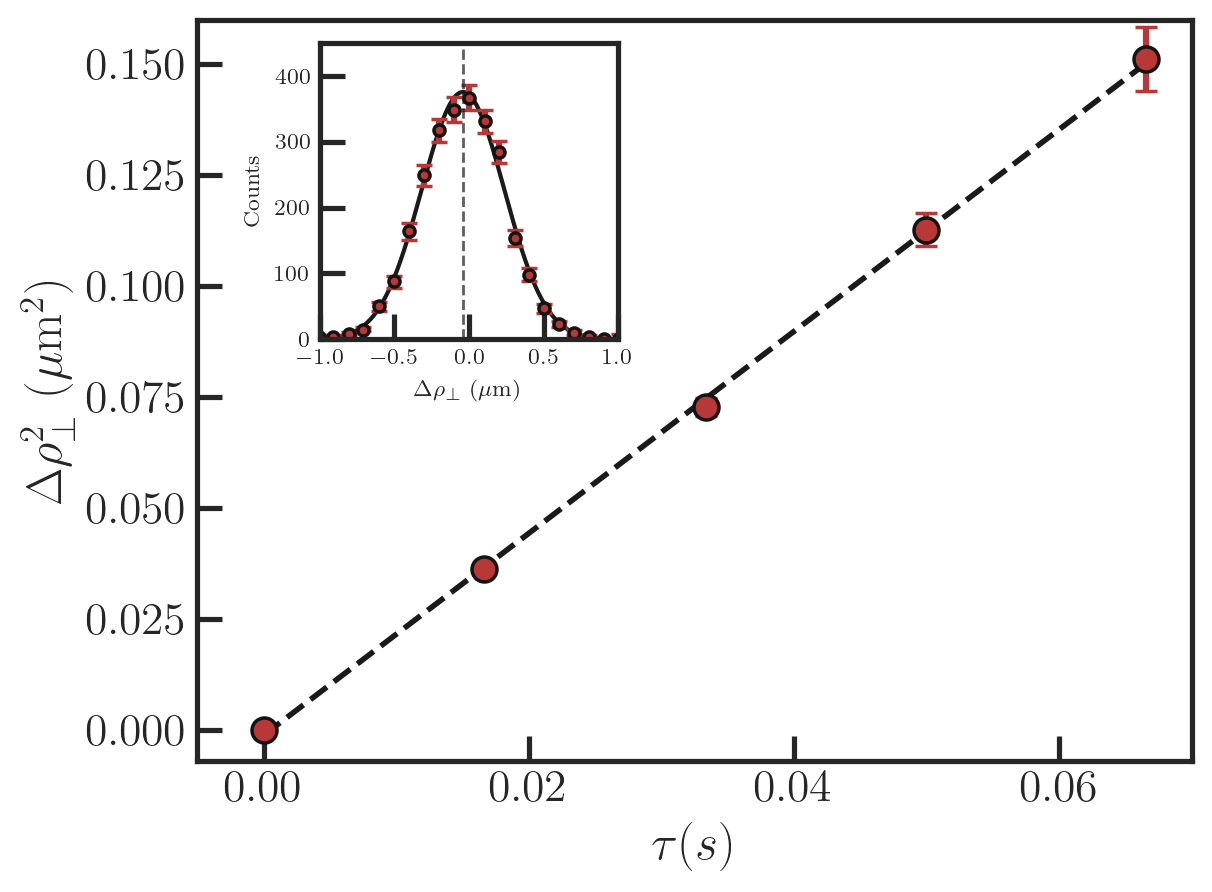

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -----------------------
# MAIN DATA 
# -----------------------
df_main = pd.read_csv('points_msd_dufresne.csv', sep=';')

x_main = df_main['Tau'].to_numpy()
y_main = df_main['Avg'].to_numpy()

coeffs = np.polyfit(x_main, y_main, 1)
slope, intercept = coeffs

x_fit_main = np.linspace(x_main.min(), x_main.max(), 500)
y_fit_main = slope * x_fit_main + intercept

lower_main = df_main['Avg'] - df_main['Lower Bound']
upper_main = df_main['Higher Bound'] - df_main['Avg']
yerr_main = [lower_main, upper_main]


# -----------------------
# INSET DATA 
# -----------------------
df_inset = pd.read_csv('points_dufresne_histo_inlet.csv', sep=';')

x_inset = df_inset['del_rho'].to_numpy()
y_inset = df_inset['Avg'].to_numpy()

lower_inset = (df_inset['Avg'] - df_inset['Lowerbound']).to_numpy()
upper_inset = (df_inset['Higherbound'] - df_inset['Avg']).to_numpy()
yerr_inset = [lower_inset, upper_inset]


def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))


A0 = y_inset.max()
mu0 = x_inset[np.argmax(y_inset)]
sigma0 = np.std(x_inset)

popt, _ = curve_fit(gaussian, x_inset, y_inset, p0=[A0, mu0, sigma0])

x_fit = np.linspace(x_inset.min(), x_inset.max(), 500)
y_fit = gaussian(x_fit, *popt)


# -----------------------
# PLOTTING
# -----------------------
fig, ax = plt.subplots()

# Main plot
ax.errorbar(
    x_main,
    y_main,
    yerr=yerr_main,
    fmt='o',
    capsize=4,
    linestyle='none'
)

ax.plot(x_fit_main, y_fit_main, color='k', linestyle='--', label='_None_', linewidth=2)
ax.set_xlim(-0.005, 0.07)
ax.set_ylim(-0.007, 0.160)
# ax.legend()
ax.set_xlabel(r'$\tau (s)$')
ax.set_ylabel(r'$\Delta \rho_\perp^2 ~(\mu \mathrm{m}^2)$')


# -----------------------
# INSET
# -----------------------
ax_inset = inset_axes(
    ax,
    width="30%",
    height="40%",
    loc='upper left',
    bbox_to_anchor=(0.1, 0, 1, 1),   
    bbox_transform=ax.transAxes
)
ax_inset.errorbar(
    x_inset,
    y_inset,
    yerr=yerr_inset,
    fmt='o',
    capsize=3,
    markersize=4,
    linestyle='none'
)

ax_inset.plot(x_fit, y_fit, color = 'k', zorder = -1, linewidth=1.5)
ax_inset.vlines(popt[1], 0, 450, color='k', linestyle='--', alpha=0.7, linewidth=1)

ax_inset.set_xlabel(r'$\Delta \rho_\perp ~(\mu \mathrm{m})$', fontsize=8)
ax_inset.set_ylabel('Counts', fontsize=8)
ax_inset.set_xlim(-1, 1)
ax_inset.set_ylim(0, 450)

ax_inset.tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.savefig('dufresne_results.pdf', transparent = True)